# Workshop 3 — Machine Learning Pipeline
## Feature Engineering + Regression Model Training

**Course:** ETL (G01) | **Program:** Data Engineering & AI  
**Part A — Steps 3 & 4:** Feature Engineering + Train Regression Model

---

### Objectives
- Engineer features from the unified dataset
- Train a regression model to predict `happiness_score`
- Evaluate the model (MAE, RMSE, R²)
- Serialize the model as `model.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Global plot style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#0d0d0d',
    'axes.edgecolor':   '#444444',
    'axes.labelcolor':  '#f0f0f0',
    'xtick.color':      '#f0f0f0',
    'ytick.color':      '#f0f0f0',
    'text.color':       '#f0f0f0',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444444',
    'figure.dpi':       120,
})

NEON = ['#00f5d4', '#f72585', '#7209b7', '#3a86ff', '#ffbe0b', '#fb5607']

PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Unified Dataset

In [2]:
df = pd.read_csv(f'{PROCESSED_DIR}unified_happiness.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (782, 12)
Columns: ['country', 'region', 'year', 'happiness_rank', 'happiness_score', 'gdp_per_capita', 'social_support', 'health_life_expectancy', 'freedom', 'generosity', 'corruption', 'dystopia_residual']


,country,region,year,happiness_rank,happiness_score,gdp_per_capita,social_support,health_life_expectancy,freedom,generosity,corruption,dystopia_residual
0,Switzerland,Western Europe,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2.51738
1,Iceland,Western Europe,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2.70201
2,Denmark,Western Europe,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2.49204
3,Norway,Western Europe,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2.46531
4,Canada,North America,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2.45176


---
## 2. Feature Engineering

### Feature Selection Justification

The target variable is `happiness_score`. We select features based on:

1. **Availability across all years** — `region` and `dystopia_residual` are absent in 2017–2019, so they are excluded from ML features to avoid data leakage and inconsistency.
2. **Correlation with target** — EDA showed strong correlations for `gdp_per_capita`, `social_support`, `health_life_expectancy`, `freedom`.
3. **No target leakage** — `happiness_rank` is derived FROM the score, so it is excluded.
4. **Categorical handling** — `country` has too many categories (156+) and would cause data leakage in time-based splits; excluded from features.

**Selected features:** `gdp_per_capita`, `social_support`, `health_life_expectancy`, `freedom`, `generosity`, `corruption`

These match exactly the fields the Kafka producer will stream (excluding `actual_happiness_score`).

In [3]:
FEATURES = [
    'gdp_per_capita',
    'social_support',
    'health_life_expectancy',
    'freedom',
    'generosity',
    'corruption',
]
TARGET = 'happiness_score'

# Drop rows with NaN in selected features or target
ml_df = df[FEATURES + [TARGET]].dropna()
print(f'ML dataset shape after dropna: {ml_df.shape}')
print(f'Target range: {ml_df[TARGET].min():.3f} – {ml_df[TARGET].max():.3f}')
ml_df.describe().round(4)

ML dataset shape after dropna: (782, 7)
Target range: 2.693 – 7.769


,gdp_per_capita,social_support,health_life_expectancy,freedom,generosity,corruption,happiness_score
count,782.0000,782.0000,782.0000,782.0000,782.0000,782.0000,782.0000
mean,0.9160,1.0784,0.6124,0.4111,0.2186,0.1254,5.3790
std,0.4073,0.3295,0.2483,0.1529,0.1223,0.1058,1.1275
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.6930
25%,0.6065,0.8694,0.4402,0.3098,0.1300,0.0542,4.5098
50%,0.9822,1.1247,0.6473,0.4310,0.2020,0.0909,5.3220
75%,1.2362,1.3272,0.8080,0.5310,0.2788,0.1559,6.1895
max,2.0960,1.6440,1.1410,0.7240,0.8381,0.5519,7.7690


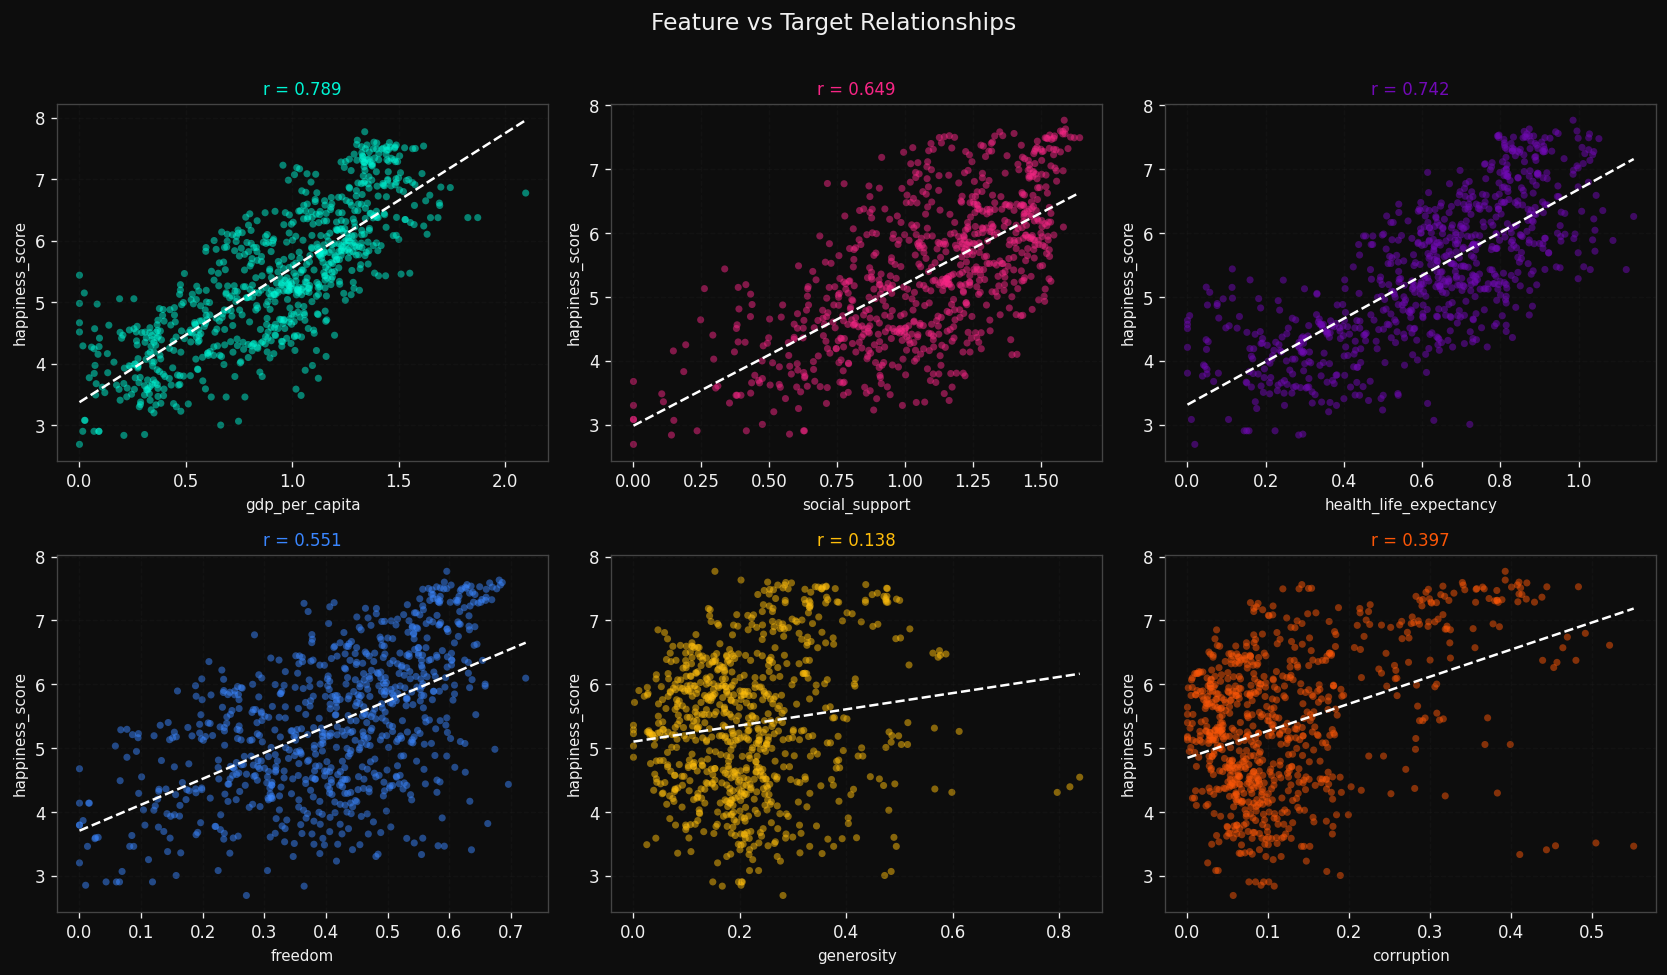

In [4]:
# Feature importance preview — scatter matrix for top 4 features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, feat in enumerate(FEATURES):
    axes[idx].scatter(ml_df[feat], ml_df[TARGET],
                      alpha=0.5, s=18, color=NEON[idx], edgecolors='none')
    # Trend line
    m, b = np.polyfit(ml_df[feat], ml_df[TARGET], 1)
    x_line = np.linspace(ml_df[feat].min(), ml_df[feat].max(), 100)
    axes[idx].plot(x_line, m*x_line + b, color='white', linewidth=1.5, linestyle='--')
    axes[idx].set_xlabel(feat, fontsize=9)
    axes[idx].set_ylabel('happiness_score', fontsize=9)
    corr_val = ml_df[feat].corr(ml_df[TARGET])
    axes[idx].set_title(f'r = {corr_val:.3f}', fontsize=10, color=NEON[idx])
    axes[idx].grid(alpha=0.2)

fig.suptitle('Feature vs Target Relationships', fontsize=14, color='#f0f0f0', y=1.01)
fig.tight_layout()
plt.savefig(f'{PROCESSED_DIR}feature_relationships.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

---
## 3. Train / Test Split

In [5]:
X = ml_df[FEATURES]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Training set : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)')

Training set : 547 rows (69.9%)
Test set     : 235 rows (30.1%)


---
## 4. Train & Compare Three Models

In [6]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DecisionTreeRegressor(max_depth=5, random_state=42))
    ]),
}

results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(pipe, X, y, cv=5, scoring='r2').mean()
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv, 'pipe': pipe, 'y_pred': y_pred}
    print(f'[{name:20s}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  CV-R²={cv:.4f}')

[Linear Regression   ]  MAE=0.4486  RMSE=0.5843  R²=0.7266  CV-R²=0.7394
[Random Forest       ]  MAE=0.4070  RMSE=0.5238  R²=0.7802  CV-R²=0.7789
[Decision Tree       ]  MAE=0.5179  RMSE=0.6680  R²=0.6427  CV-R²=0.7035


---
## 5. Model Evaluation Visualizations

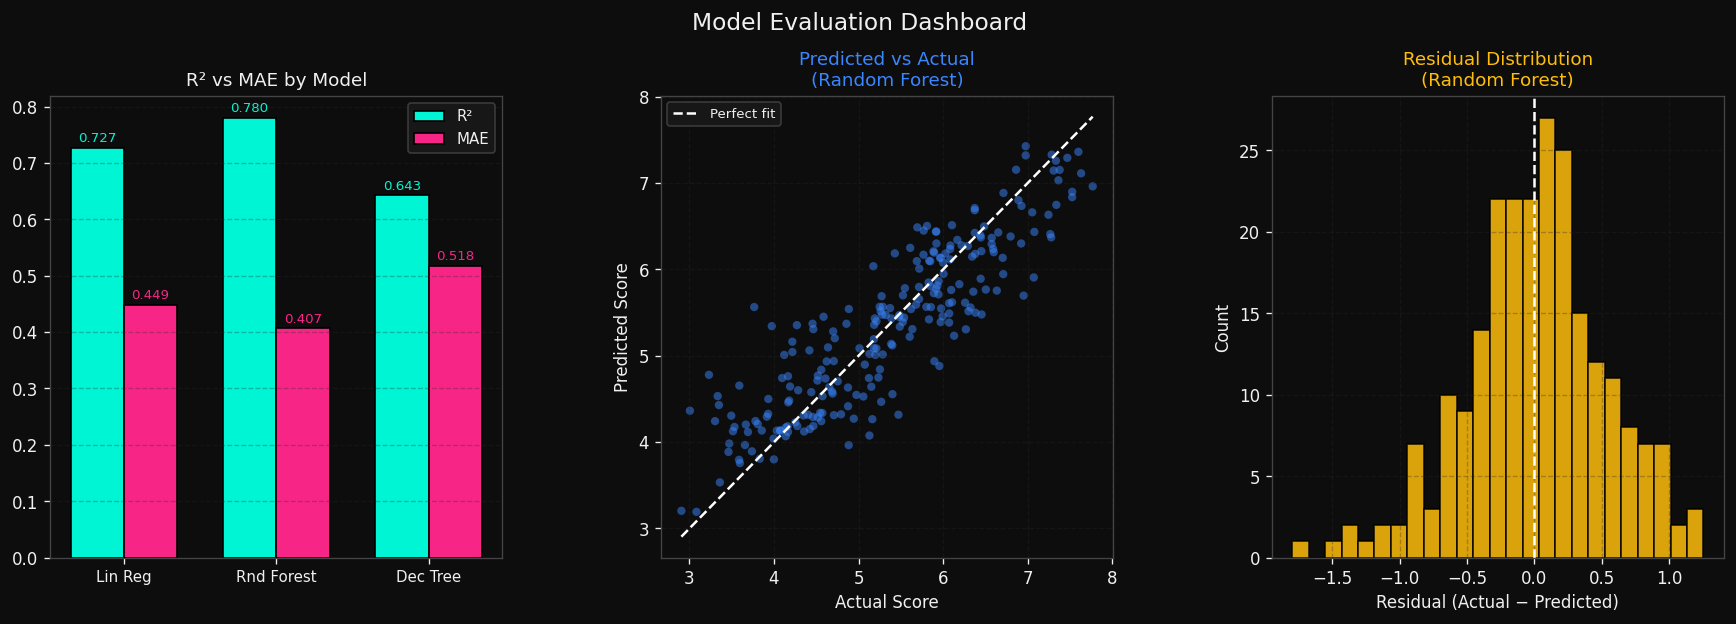

Best model: Random Forest  R²=0.7802


In [7]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Metric comparison bar chart ---
ax0 = fig.add_subplot(gs[0])
model_names = list(results.keys())
r2_vals  = [results[m]['R2']  for m in model_names]
mae_vals = [results[m]['MAE'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
bars1 = ax0.bar(x - width/2, r2_vals,  width, label='R²',  color='#00f5d4', edgecolor='#000')
bars2 = ax0.bar(x + width/2, mae_vals, width, label='MAE', color='#f72585', edgecolor='#000')
for bar in bars1:
    ax0.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#00f5d4')
for bar in bars2:
    ax0.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#f72585')
ax0.set_xticks(x)
ax0.set_xticklabels(['Lin Reg', 'Rnd Forest', 'Dec Tree'], fontsize=9)
ax0.set_title('R² vs MAE by Model', fontsize=11, color='#f0f0f0')
ax0.legend(fontsize=9)
ax0.grid(axis='y', alpha=0.3)

# --- Predicted vs Actual for best model ---
best_name = max(results, key=lambda m: results[m]['R2'])
y_pred_best = results[best_name]['y_pred']

ax1 = fig.add_subplot(gs[1])
ax1.scatter(y_test, y_pred_best, alpha=0.5, s=25, color='#3a86ff', edgecolors='none')
lo, hi = y_test.min(), y_test.max()
ax1.plot([lo, hi], [lo, hi], 'w--', linewidth=1.5, label='Perfect fit')
ax1.set_xlabel('Actual Score', fontsize=10)
ax1.set_ylabel('Predicted Score', fontsize=10)
ax1.set_title(f'Predicted vs Actual\n({best_name})', fontsize=11, color='#3a86ff')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# --- Residuals distribution ---
ax2 = fig.add_subplot(gs[2])
residuals = y_test.values - y_pred_best
ax2.hist(residuals, bins=25, color='#ffbe0b', edgecolor='#000', alpha=0.85)
ax2.axvline(0, color='white', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Residual (Actual − Predicted)', fontsize=10)
ax2.set_ylabel('Count', fontsize=10)
ax2.set_title(f'Residual Distribution\n({best_name})', fontsize=11, color='#ffbe0b')
ax2.grid(alpha=0.3)

fig.suptitle('Model Evaluation Dashboard', fontsize=14, color='#f0f0f0', y=1.02)
plt.savefig(f'{PROCESSED_DIR}model_evaluation.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'Best model: {best_name}  R²={results[best_name]["R2"]:.4f}')

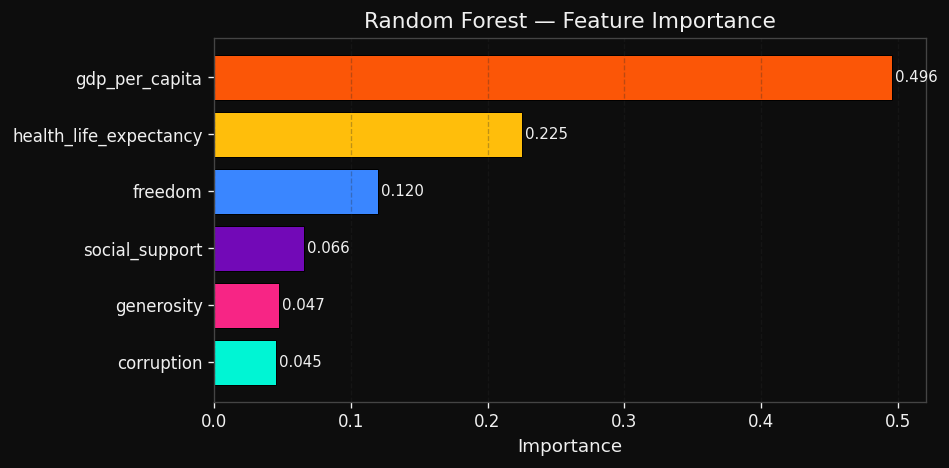

In [8]:
# Feature importance (Random Forest)
rf_pipe = results['Random Forest']['pipe']
importances = rf_pipe.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [NEON[i % len(NEON)] for i in range(len(feat_imp))]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='#000', linewidth=0.6)
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#f0f0f0')
ax.set_title('Random Forest — Feature Importance', fontsize=13, color='#f0f0f0')
ax.set_xlabel('Importance', fontsize=11)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.savefig(f'{PROCESSED_DIR}feature_importance.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

---
## 6. Final Metrics Summary

In [9]:
metrics_rows = []
for name in results:
    r = results[name]
    metrics_rows.append({
        'Model':  name,
        'MAE':    round(r['MAE'],  4),
        'RMSE':   round(r['RMSE'], 4),
        'R²':     round(r['R2'],   4),
        'CV R²':  round(r['CV_R2'],4),
    })
metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print(metrics_df.to_string())
print(f'\nSelected model for serialization: {best_name}')

                      MAE    RMSE      R²   CV R²
Model                                            
Linear Regression  0.4486  0.5843  0.7266  0.7394
Random Forest      0.4070  0.5238  0.7802  0.7789
Decision Tree      0.5179  0.6680  0.6427  0.7035

Selected model for serialization: Random Forest


---
## 7. Serialize Model

We serialize the best-performing pipeline (includes `StandardScaler` + model) so the Kafka consumer can load it and perform inference on raw feature values without needing to re-scale.

In [10]:
best_pipeline = results[best_name]['pipe']

# Save model metadata alongside the pickle
model_metadata = {
    'model_name':    best_name,
    'features':      FEATURES,
    'target':        TARGET,
    'test_mae':      round(results[best_name]['MAE'], 4),
    'test_rmse':     round(results[best_name]['RMSE'], 4),
    'test_r2':       round(results[best_name]['R2'], 4),
    'train_rows':    int(X_train.shape[0]),
    'test_rows':     int(X_test.shape[0]),
}

model_path    = f'{MODELS_DIR}model.pkl'
metadata_path = f'{MODELS_DIR}model_metadata.json'

joblib.dump(best_pipeline, model_path)

import json
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f'Model saved to  : {model_path}')
print(f'Metadata saved  : {metadata_path}')
print(f'\nModel metadata:')
print(json.dumps(model_metadata, indent=2))

Model saved to  : ../models/model.pkl
Metadata saved  : ../models/model_metadata.json

Model metadata:
{
  "model_name": "Random Forest",
  "features": [
    "gdp_per_capita",
    "social_support",
    "health_life_expectancy",
    "freedom",
    "generosity",
    "corruption"
  ],
  "target": "happiness_score",
  "test_mae": 0.407,
  "test_rmse": 0.5238,
  "test_r2": 0.7802,
  "train_rows": 547,
  "test_rows": 235
}


In [11]:
# Sanity check — load model back and verify inference
loaded_model = joblib.load(model_path)
sample = pd.DataFrame([{
    'gdp_per_capita':         1.2,
    'social_support':         0.8,
    'health_life_expectancy': 0.9,
    'freedom':                0.6,
    'generosity':             0.3,
    'corruption':             0.1,
}])
prediction = loaded_model.predict(sample)[0]
print(f'Sample prediction (Colombia-like values): {prediction:.4f}')
print('Model serialization verified. Pipeline ready for Kafka consumer.')

Sample prediction (Colombia-like values): 6.2798
Model serialization verified. Pipeline ready for Kafka consumer.
